In [18]:
import sys
from pathlib import Path
import pandas as pd
from math import floor
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from datetime import timedelta

sys.path.append(str(Path().resolve().parent))

In [3]:
from src.config import ROOT_PROJECT, RAW_DATA, PROCESSED_DATA
from src.ingestion import hrv_recuperacao, sleep
from src.transforms import base
from src.analysis import correlation
from src.utils import datetime_utils

x, y
[1 2 3 4 5] [ 2  4  6  8 10]
mean
3.0 6.0
centered
[-2. -1.  0.  1.  2.] [-4. -2.  0.  2.  4.]
covariannce_sum
20.0
squared_deviation
10.0 40.0
400.0
1.0


In [4]:
df_sleep = sleep.load_sono_resumo()

print(df_sleep)

print(df_sleep.columns.to_list())

           data  duracao_total_min  sono_profundo_min  sono_leve_min  \
0    2025-04-15              437.0                109            235   
1    2025-04-16              415.0                101            226   
2    2025-04-17              422.3                113            259   
3    2025-04-18              438.0                104            258   
4    2025-04-19              422.9                 85            314   
..          ...                ...                ...            ...   
429  2026-06-18              413.0                 49            301   
430  2026-06-19              395.0                 82            224   
431  2026-06-20              401.0                106            208   
432  2026-06-21              384.0                113            219   
433  2026-06-22              399.7                 60            270   

     sono_rem_min  acordado_min  vezes_acordado  momentos_agitados  \
0              93             0             0.0                Na

0      7:17
1      6:55
2      7:02
3      7:18
4      7:03
       ... 
429    6:53
430    6:35
431    6:41
432    6:24
433    6:40
Name: duracao_total_h, Length: 434, dtype: str


In [6]:
df_sleep['data'] = pd.to_datetime(df_sleep['data'])

df_agg_month = base.agg_by_mes(df_sleep, "data", sleep_duration_mean = ("duracao_total_min", "mean"), 
                               sleep_depth_mean = ("sono_profundo_min", "mean"))



df_agg_month['mean_duration'] = df_agg_month['sleep_duration_mean'].apply(datetime_utils.to_hour_label)

df_agg_month['sleep_depth_mean'] = df_agg_month['sleep_depth_mean'].apply(datetime_utils.to_hour_label)
print(df_agg_month)

            sleep_duration_mean sleep_depth_mean mean_duration
data                                                          
2025-04-30           440.943750            01:39         07:20
2025-05-31           421.267742            01:30         07:01
2025-06-30           409.020000            01:23         06:49
2025-07-31           420.851613            01:19         07:00
2025-08-31           414.529032            01:19         06:54
2025-09-30           402.506667            01:32         06:42
2025-10-31           397.100000            01:35         06:37
2025-11-30           406.790000            01:45         06:46
2025-12-31           368.916129            01:24         06:08
2026-01-31           400.703226            01:25         06:40
2026-02-28           426.767857            01:43         07:06
2026-03-31           418.406452            01:27         06:58
2026-04-30           417.763333            01:40         06:57
2026-05-31           421.035484            01:27       

In [7]:
# corr = correlation.correlation_matrix(df_sleep[['duracao_total_min', 'sono_profundo_min']], method= "pearson")

In [ ]:
corr = correlation.correlation_target(df_sleep, 'duracao_total_min', method="pearson")

print(corr)

duracao_total_min            1.000000
sono_profundo_min            0.339701
sono_leve_min                0.735239
sono_rem_min                 0.440779
acordado_min                 0.097836
vezes_acordado               0.089276
momentos_agitados            0.634995
score_geral                  0.665017
score_rem_pct                0.179934
score_deep_pct              -0.263378
score_light_pct              0.069940
hrv_medio_noite             -0.154659
fc_media_sono               -0.092465
fc_repouso                  -0.013043
respiracao_media             0.007445
respiracao_minima           -0.057877
respiracao_maxima            0.079987
stress_medio_sono           -0.110988
body_battery_variacao        0.489748
sono_necessidade_baseline         NaN
sono_necessidade_real        0.045902
Name: duracao_total_min, dtype: float64


Text(0.5, 1.0, 'Total sono vs total sono leve')

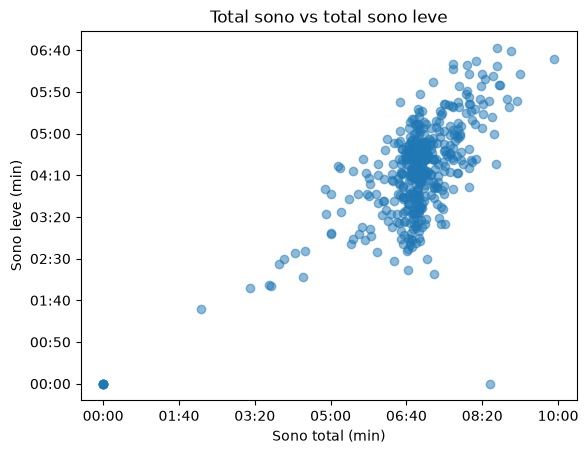

In [19]:
fig, ax = plt.subplots()

ax.scatter(
    df_sleep['duracao_total_min'],
    df_sleep['sono_leve_min'],
    alpha=0.5
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: datetime_utils.to_hour_label(x))
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: datetime_utils.to_hour_label(x))
)

plt.xlabel("Sono total (min)")
plt.ylabel("Sono leve (min)")
plt.title("Total sono vs total sono leve")

Text(0.5, 1.0, 'Total sono vs total sono leve')

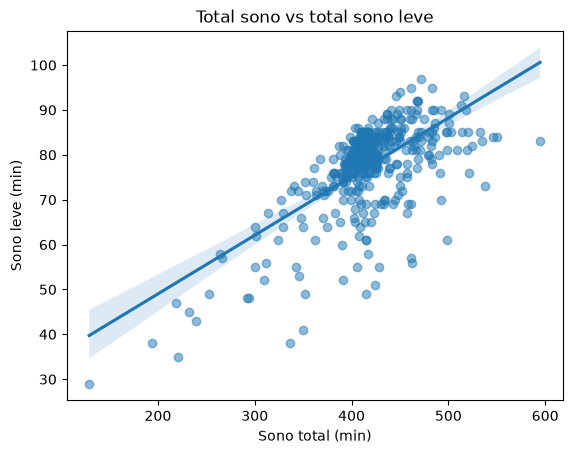

In [11]:
sns.regplot(
    data=df_sleep,
    x="duracao_total_min",
    y="score_geral",
    scatter_kws={"alpha":0.5}
)

plt.xlabel("Sono total (min)")
plt.ylabel("Sono leve (min)")
plt.title("Total sono vs total sono leve")

In [16]:
print(df_sleep['duracao_total_min'])

0      437.0
1      415.0
2      422.3
3      438.0
4      422.9
       ...  
429    413.0
430    395.0
431    401.0
432    384.0
433    399.7
Name: duracao_total_min, Length: 434, dtype: float64
